# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: CRUZADO, JOHN CLARENCE
- _Student No._: 2024-03034
- _Section_: THU-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="fig1.png" alt="Figure 1" width=45%>

Figure 1: Plot of $f(x)=(x-2)^2(e^x - x^3 - 2)$

Figure 1 shows the plot of the function we are investigating. In this report, we attempt to employ four (4) different root-finding methods to numerically obtain the three (3) roots of $f(x)$, which are located at $x=-1.19$, $x=2.00$, and $x=4.60$.

<img src="fig2.png" alt="Figure 2" width=30%> <img src="fig3.png" alt="Figure 3" width=30%> <img src="fig4.png" alt="Figure 4" width=30%>

Figures 2-4: Convergence Plot of the different Root-Finding methods at (2) $x=-1.19$, (3) $x=2.00$, and (4) $x=4.60$.

In figures 2-4, we employ the different root-finding methods, namely the Fixed Point Method, Bisection Method, Newton's Method, and Secant Method, and compare the convergence of $x$ values of each algorithm. The graph shows that all methods are reliable in finding the root in no more than 50 iterations, though this number is dependent on the initial guesses.

The Fixed-Point method is the simplest to implement, but its convergence heavily depends on the chosen rearrangement of the function. Generally, it takes the longest to converge, generally taking more iterations.

The Bisection Method is reliable when the initial guess interval contains a sign change. However, it is severely limited to the condition that such changes exist. Like the Fixed-Point method, it generally takes longer to converge, though it is slightly faster than the former.

Newton's Method is a special form of the Fixed-Point Method. It has a better edge in setting up the equivalent function $g(x)$ in finding the root, but it relies heavily on an initial guess and a non-zero derivative (to avoid division by zero).

The Secand Method avoids calculating the derivative and it can converge quickly, however, it is highly unstable for certain starting values.

---
The Fixed-Point method was coded by transforming the function $f(x)=0$ into an equivalent function $x_{k+1}=g(x_{k})$, and using $g(x)$ to iteratively update the value of $x$. When $x_{k+1} - x_{k} \geq tol$ where $tol$ is the acceptable deviation near the actual root, then we stop and return the latest iteration of $x$ as the root.

The BisectIon method checks when the endpoints have opposite function signs. Then, we repeatedly calculate the midpoint of the intervals and update the endpoints, keeping the ones containing the sign change. The algorithm continues until the distance between the endpoints is sufficiently small.

Newton's method is a special form of the Fixed-Point method where we make use of the derivative of a function at a point, which is actually the slope of the tangent line to the function. We then update the values of the initial guess based on the formula and repeatedly take the intersection of the tangent line to the x-axis until we reach a sufficiently acceptable value.

Secant method is similar to Newton's method, except for the part where we use the derivative, instead, it approximates it using the a form similar to the limit definition of the derivative. We start with two points as our initial guess, and we

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

Iterations: 25
Root: x = -1.1926857647124451
Iterations: 2
Root: x = 2
Iterations: 40
Root: x = 4.595863552555816
Iterations = 27
Root: x = -1.1926857680082321
f(a) and f(b) must be different signs. Bisection method is not applicable.
Iterations = 26
Root: x = 4.595863565802574
Iterations: 7
Root: x = -1.1926857650225988
Iterations: 29
Root: x = 2.000000005203756
Iterations: 9
Root: x = 4.595863564922455
Iterations: 8
Root: x = -1.1926857650225988
Iterations: 42
Root: x = 2.00000001069564
Iterations: 9
Root: x = 4.595863564922471


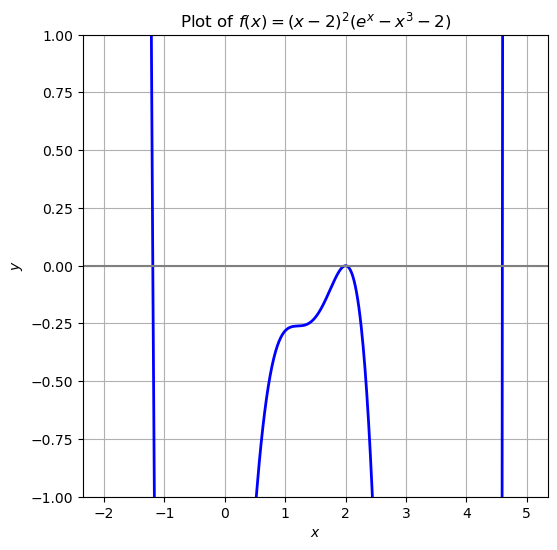

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 5,701)

def f(x):
    return (x-2) ** 2 * (np.exp(x) - x ** 3 - 2)

def df(x):
    return (2*x - 4) * (np.exp(x) - x ** 3 - 2) + (x - 2) ** 2 * (np.exp(x) - 3 * x ** 2)

def lenrange(iterations):
    return range(1, len(iterations)+1)

plt.figure(figsize=(6,6))
plt.plot(x,f(x),color='blue',lw=2,label=r"$f(x)$")
#plt.plot(x,df(x),color='purple',lw=2,ls=":",label=rf"$f'(x)$")
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.ylim(-1,1)
plt.grid(True)
plt.axhline(0,color="gray")
plt.title(r"Plot of $f(x)=(x-2)^2(e^x-x^3-2)$")

# FIXED POINT METHOD

def g1(x):
    inner = np.exp(x) - 2
    return np.sign(inner) * (np.abs(inner) ** (1/3))

def g2(x):
    return 2

def g3(x):
    inner = x**3 + 2
    if inner <= 0:
        raise ValueError(f"Domain error: x={x} results in log of a non-positive number.")
    return np.log(inner)

def fixedpoint(g,x0,tol=1e-8,max_iter=1000):
    iteration = 0
    history = [x0]
    while iteration < max_iter:
        x1 = g(x0)
        iteration += 1
        
        if abs(x1 - x0) < tol:
            print(f"Iterations: {iteration}")
            print(f"Root: x = {x1}")
            history.append(x1)
            return x1, history
        
        x0 = x1
        history.append(x0)

x0 = 4
fp1, hfp1 = fixedpoint(g1,x0)
fp2, hfp2 = fixedpoint(g2,x0)
fp3, hfp3 = fixedpoint(g3,x0)

# BISECTION METHOD

def bisection(f,a,b,tol=1e-8,max_iter=1000):    
    iteration = 0
    history = [(a+b)/2]

    if f(a) == 0:
        c = a
        print(f"Iterations = {iteration}")
        print(f"Root: x = {c}")
        return c, history

    if f(b) == 0:
        c = b
        print(f"Iterations = {iteration}")
        print(f"Root: x = {c}")
        return c, history

    if f(a) * f(b) >= 0:
        print("f(a) and f(b) must be different signs. Bisection method is not applicable.")
        return None, history
    
    while abs(b - a) / 2 > tol and iteration < max_iter:
        c = (a + b) / 2
        if f(c) == 0:
            print(f"Iterations = {iteration}")
            print(f"Root: x = {c}")
            return c, history
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
        iteration += 1
        history.append(c)
    
    print(f"Iterations = {iteration}")
    print(f"Root: x = {c}")
    return c, history

bis1, hbis1 = bisection(f,-2,0)
bis2, hbis2 = bisection(f,1,3)
bis3, hbis3 = bisection(f,4,5)

# NEWTON'S METHOD

def newton(f,df,x0,tol=1e-8,max_iter=1000):
    iteration = 0
    history = [x0]
    
    while iteration < max_iter:
        x1 = x0 - f(x0) / df(x0)
        iteration += 1
        
        if abs(x1 - x0) < tol:
            print(f"Iterations: {iteration}")
            print(f"Root: x = {x1}")
            history.append(x1)
            return x1, history
        
        x0 = x1
        history.append(x0)

newt1, hnewt1 = newton(f,df,-2)
newt2, hnewt2= newton(f,df,3)
newt3, hnewt3 = newton(f,df,6)

# SECANT METHOD

def secant(f,x0,x1,tol=1e-8,max_iter=1000):
    iteration = 0
    history = [x1]
    
    while iteration < max_iter:
        fx0 = f(x0)
        fx1 = f(x1)
        x2 = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        iteration += 1
        
        if abs(x2 - x1) < tol:
            print(f"Iterations: {iteration}")
            print(f"Root: x = {x2}")
            history.append(x2)
            return x2, history
        
        x0, x1 = x1, x2
        history.append(x1)

sec1, hsec1 = secant(f,-2,-1)
sec2, hsec2 = secant(f,0,3)
sec3, hsec3 = secant(f,5,6)


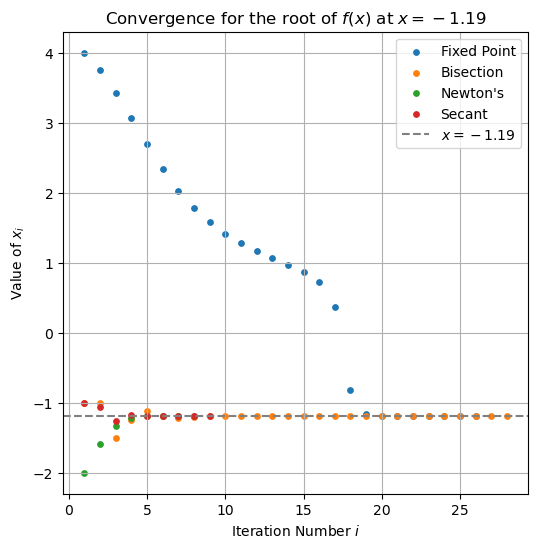

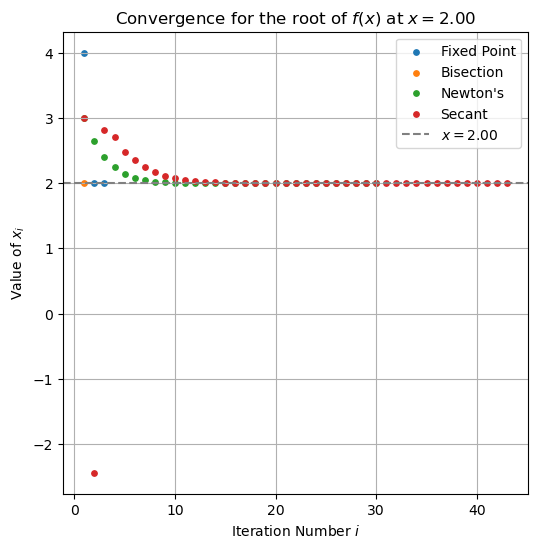

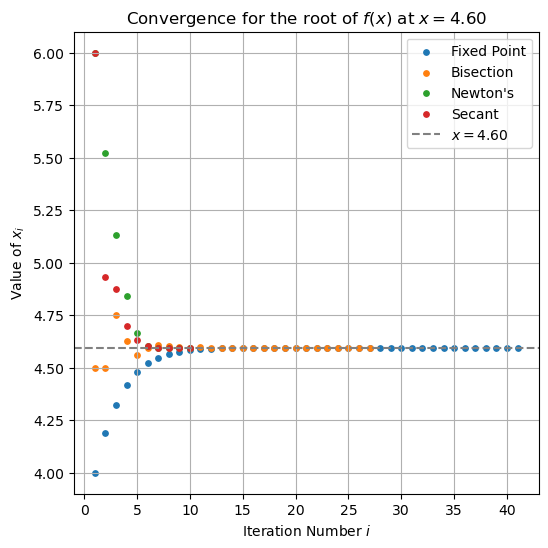

In [3]:
# PLOT FOR X = -1.19

plt.figure(figsize=(6,6))

plt.title(rf"Convergence for the root of $f(x)$ at $x={fp1:.2f}$")
plt.xlabel(rf"Iteration Number $i$")
plt.ylabel(rf"Value of $x_i$")

plt.scatter(lenrange(hfp1), hfp1, s=15, label="Fixed Point")
plt.scatter(lenrange(hbis1), hbis1, s=15, label="Bisection")
plt.scatter(lenrange(hnewt1), hnewt1, s=15, label="Newton's")
plt.scatter(lenrange(hsec1), hsec1, s=15, label="Secant")

plt.axhline(fp1,color='gray',ls="--", label=rf"$x={fp1:.2f}$")

plt.grid(True)
plt.legend()

# PLOT FOR X = 2.00

plt.figure(figsize=(6,6))

plt.title(rf"Convergence for the root of $f(x)$ at $x={fp2:.2f}$")
plt.xlabel(rf"Iteration Number $i$")
plt.ylabel(rf"Value of $x_i$")

plt.scatter(lenrange(hfp2), hfp2, s=15, label="Fixed Point")
plt.scatter(lenrange(hbis2), hbis2, s=15, label="Bisection")
plt.scatter(lenrange(hnewt2), hnewt2, s=15, label="Newton's")
plt.scatter(lenrange(hsec2), hsec2, s=15, label="Secant")

plt.axhline(fp2,color='gray',ls="--", label=rf"$x={fp2:.2f}$")

plt.grid(True)
plt.legend()

# PLOT FOR X = 4.59

plt.figure(figsize=(6,6))

plt.title(rf"Convergence for the root of $f(x)$ at $x={fp3:.2f}$")
plt.xlabel(rf"Iteration Number $i$")
plt.ylabel(rf"Value of $x_i$")

plt.scatter(lenrange(hfp3), hfp3, s=15, label="Fixed Point")
plt.scatter(lenrange(hbis3), hbis3, s=15, label="Bisection")
plt.scatter(lenrange(hnewt3), hnewt3, s=15, label="Newton's")
plt.scatter(lenrange(hsec3), hsec3, s=15, label="Secant")

plt.axhline(fp3,color='gray',ls="--", label=rf"$x={fp3:.2f}$")

plt.grid(True)
plt.legend()

plt.show()

#### Problem 1 code summary

We investigated the function (rewritten as $f(x)=(x-2)^2(e^x-x^3-2)$ using 4 root-finding methods, namely the Fixed Point, Bisection, Newton, and Secant methods. Each method involves iterating and updating the input guess value (while recording the history of each iteration) as it converges down to the actual numerical root. 

---